In [ ]:
Аттестация 2

In [2]:
import pandas as pd

# Загружаем файл
df_full = pd.read_parquet('part-0.parquet')

print(f"Всего строк: {len(df_full)}")
print(f"Всего колонок: {len(df_full.columns)}")
print("\nПервые 10 колонок:")
print(df_full.columns[:10].tolist())

Всего строк: 3219569
Всего колонок: 213

Первые 10 колонок:
['inn', 'ogrn', 'region', 'region_taxcode', 'creation_date', 'dissolution_date', 'age', 'eligible', 'exemption_criteria', 'financial']


In [3]:
# Список из 20 важнейших финансовых колонок
selected_columns = [
    # Идентификаторы и базовые поля
    'inn',
    'year',
    'region',
    'okved',
    
    # Основные финансовые показатели (форма 0710099)
    'line_2110',  # Выручка
    'line_2120',  # Себестоимость продаж
    'line_2100',  # Валовая прибыль (убыток)
    'line_2200',  # Прибыль (убыток) от продаж
    'line_2300',  # Прибыль (убыток) до налогообложения
    'line_2400',  # Чистая прибыль (убыток)
    
    # Балансовые показатели
    'line_1100',  # Внеоборотные активы
    'line_1200',  # Оборотные активы
    'line_1600',  # БАЛАНС (Активы)
    'line_1300',  # Капитал и резервы
    'line_1400',  # Долгосрочные обязательства
    'line_1500',  # Краткосрочные обязательства
    'line_1700',  # БАЛАНС (Пассивы)
    
    # Дополнительные полезные поля
    'outlier',    # Флаг аномальной отчетности
    'filed',      # Флаг наличия отчетности
    'okopf'       # Организационно-правовая форма
]

# Оставляем только те колонки, которые реально есть в данных
available_cols = [col for col in selected_columns if col in df_full.columns]
print(f"Найдено колонок из списка: {len(available_cols)}")

# Если каких-то колонок нет, добавим другие финансовые показатели до 20
if len(available_cols) < 20:
    # Добавляем еще финансовые строки из отчета о прибылях и убытках
    extra_cols = ['line_2210', 'line_2220', 'line_2310', 'line_2320', 'line_2330', 
                  'line_2340', 'line_2350', 'line_2410', 'line_2421', 'line_2430',
                  'line_2450', 'line_2460', 'line_2510', 'line_2520', 'line_2530']
    for col in extra_cols:
        if col in df_full.columns and col not in available_cols:
            available_cols.append(col)
        if len(available_cols) >= 20:
            break

# Оставляем ровно 20 колонок
final_cols = available_cols[:20]
print(f"Итоговое количество колонок: {len(final_cols)}")
print("\nВыбранные колонки:")
for i, col in enumerate(final_cols, 1):
    print(f"  {i}. {col}")

# Берем 1000 случайных строк (для репрезентативности выборки)
df = df_full[final_cols].sample(n=1000, random_state=42)

print(f"\n✅ Итоговый датасет: {df.shape[0]} строк, {df.shape[1]} колонок")
print("\nПервые 5 строк:")
df.head()

Найдено колонок из списка: 19
Итоговое количество колонок: 20

Выбранные колонки:
  1. inn
  2. region
  3. okved
  4. line_2110
  5. line_2120
  6. line_2100
  7. line_2200
  8. line_2300
  9. line_2400
  10. line_1100
  11. line_1200
  12. line_1600
  13. line_1300
  14. line_1400
  15. line_1500
  16. line_1700
  17. outlier
  18. filed
  19. okopf
  20. line_2210

✅ Итоговый датасет: 1000 строк, 20 колонок

Первые 5 строк:


,inn,region,okved,line_2110,line_2120,line_2100,line_2200,line_2300,line_2400,line_1100,line_1200,line_1600,line_1300,line_1400,line_1500,line_1700,outlier,filed,okopf,line_2210
1529796,5535001002,omsk,85.42.10,11008.0,-8584.0,2424.0,1844.0,1414.0,1052.0,8558.0,2597.0,11155.0,9805.0,NaN,1350.0,11155.0,0.0,1.0,75500,NaN
138300,1001230827,karelia,93.11,3519.0,-3051.0,NaN,468.0,468.0,392.0,NaN,1988.0,1988.0,10.0,1948.0,30.0,1988.0,0.0,1.0,12300,NaN
896268,3808140332,irkutsk,61.10,92392.0,-58951.0,33441.0,18378.0,17888.0,14647.0,25416.0,14687.0,40103.0,24327.0,NaN,15776.0,40103.0,0.0,1.0,12300,NaN
2524487,7727749317,moscow city,49.32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,12300,NaN
953839,3907028194,kaliningrad,71.11.10,15649.0,-10272.0,NaN,5377.0,5409.0,5091.0,571.0,16327.0,16898.0,2909.0,NaN,13989.0,16898.0,0.0,1.0,12300,NaN


In [4]:
# Словарь переименования колонок (line_XXXX -> понятное название)
rename_dict = {
    'inn': 'ИНН',
    'region': 'Регион',
    'okved': 'ОКВЭД',
    'line_2110': 'Выручка',
    'line_2120': 'Себестоимость',
    'line_2100': 'Валовая_прибыль',
    'line_2200': 'Прибыль_от_продаж',
    'line_2210': 'Коммерческие_расходы',
    'line_2300': 'Прибыль_до_налогов',
    'line_2400': 'Чистая_прибыль',
    'line_1100': 'Внеоборотные_активы',
    'line_1200': 'Оборотные_активы',
    'line_1600': 'Активы_всего',
    'line_1300': 'Капитал',
    'line_1400': 'Долгосрочные_обязательства',
    'line_1500': 'Краткосрочные_обязательства',
    'line_1700': 'Пассивы_всего',
    'outlier': 'Аномалия',
    'filed': 'Отчетность_сдана',
    'okopf': 'ОКОПФ'
}

df = df.rename(columns=rename_dict)

# Заменяем отрицательные значения на положительные 
# (в бухгалтерии расходы часто с минусом, для анализа удобнее модуль)
for col in ['Себестоимость', 'Коммерческие_расходы']:
    if col in df.columns:
        df[col] = df[col].abs()

print("✅ Колонки переименованы")
print("\nНазвания колонок:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

print("\nПервые 3 строки:")
df.head(3)

✅ Колонки переименованы

Названия колонок:
  1. ИНН
  2. Регион
  3. ОКВЭД
  4. Выручка
  5. Себестоимость
  6. Валовая_прибыль
  7. Прибыль_от_продаж
  8. Прибыль_до_налогов
  9. Чистая_прибыль
  10. Внеоборотные_активы
  11. Оборотные_активы
  12. Активы_всего
  13. Капитал
  14. Долгосрочные_обязательства
  15. Краткосрочные_обязательства
  16. Пассивы_всего
  17. Аномалия
  18. Отчетность_сдана
  19. ОКОПФ
  20. Коммерческие_расходы

Первые 3 строки:


,ИНН,Регион,ОКВЭД,Выручка,Себестоимость,Валовая_прибыль,Прибыль_от_продаж,Прибыль_до_налогов,Чистая_прибыль,Внеоборотные_активы,Оборотные_активы,Активы_всего,Капитал,Долгосрочные_обязательства,Краткосрочные_обязательства,Пассивы_всего,Аномалия,Отчетность_сдана,ОКОПФ,Коммерческие_расходы
1529796,5535001002,omsk,85.42.10,11008.0,8584.0,2424.0,1844.0,1414.0,1052.0,8558.0,2597.0,11155.0,9805.0,NaN,1350.0,11155.0,0.0,1.0,75500,NaN
138300,1001230827,karelia,93.11,3519.0,3051.0,NaN,468.0,468.0,392.0,NaN,1988.0,1988.0,10.0,1948.0,30.0,1988.0,0.0,1.0,12300,NaN
896268,3808140332,irkutsk,61.10,92392.0,58951.0,33441.0,18378.0,17888.0,14647.0,25416.0,14687.0,40103.0,24327.0,NaN,15776.0,40103.0,0.0,1.0,12300,NaN


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Настройка отображения графиков
plt.style.use('ggplot')
sns.set_palette('Set2')

# 1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА
print("=" * 60)
print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА ФИНАНСОВЫХ ПОКАЗАТЕЛЕЙ (тыс. руб.)")
print("=" * 60)

# Выбираем только числовые финансовые колонки
numeric_cols = ['Выручка', 'Себестоимость', 'Валовая_прибыль', 'Прибыль_от_продаж',
                'Прибыль_до_налогов', 'Чистая_прибыль', 'Внеоборотные_активы',
                'Оборотные_активы', 'Активы_всего', 'Капитал', 
                'Долгосрочные_обязательства', 'Краткосрочные_обязательства', 'Пассивы_всего']

# Фильтруем только существующие колонки
numeric_cols = [col for col in numeric_cols if col in df.columns]

print(df[numeric_cols].describe())

ОПИСАТЕЛЬНАЯ СТАТИСТИКА ФИНАНСОВЫХ ПОКАЗАТЕЛЕЙ (тыс. руб.)
            Выручка  Себестоимость  Валовая_прибыль  Прибыль_от_продаж  \
count  4.840000e+02   4.860000e+02     1.890000e+02       5.050000e+02   
mean   3.076862e+05   2.410138e+05     1.619990e+05       1.614698e+04   
std    2.998853e+06   2.204961e+06     1.332256e+06       2.060557e+05   
min    0.000000e+00   0.000000e+00    -1.964089e+06      -2.391598e+06   
25%    1.494000e+03   1.040750e+03     1.330000e+02       0.000000e+00   
50%    1.041050e+04   7.761000e+03     2.292000e+03       3.700000e+02   
75%    4.358050e+04   3.477975e+04     1.720300e+04       2.512000e+03   
max    5.710934e+07   4.034567e+07     1.676367e+07       2.732455e+06   

       Прибыль_до_налогов  Чистая_прибыль  Внеоборотные_активы  \
count        5.460000e+02    5.590000e+02         3.520000e+02   
mean         1.590381e+04    1.258811e+04         9.918834e+04   
std          1.462066e+05    1.154645e+05         6.457328e+05   
min       

После фильтрации осталось компаний: 438 из 1000


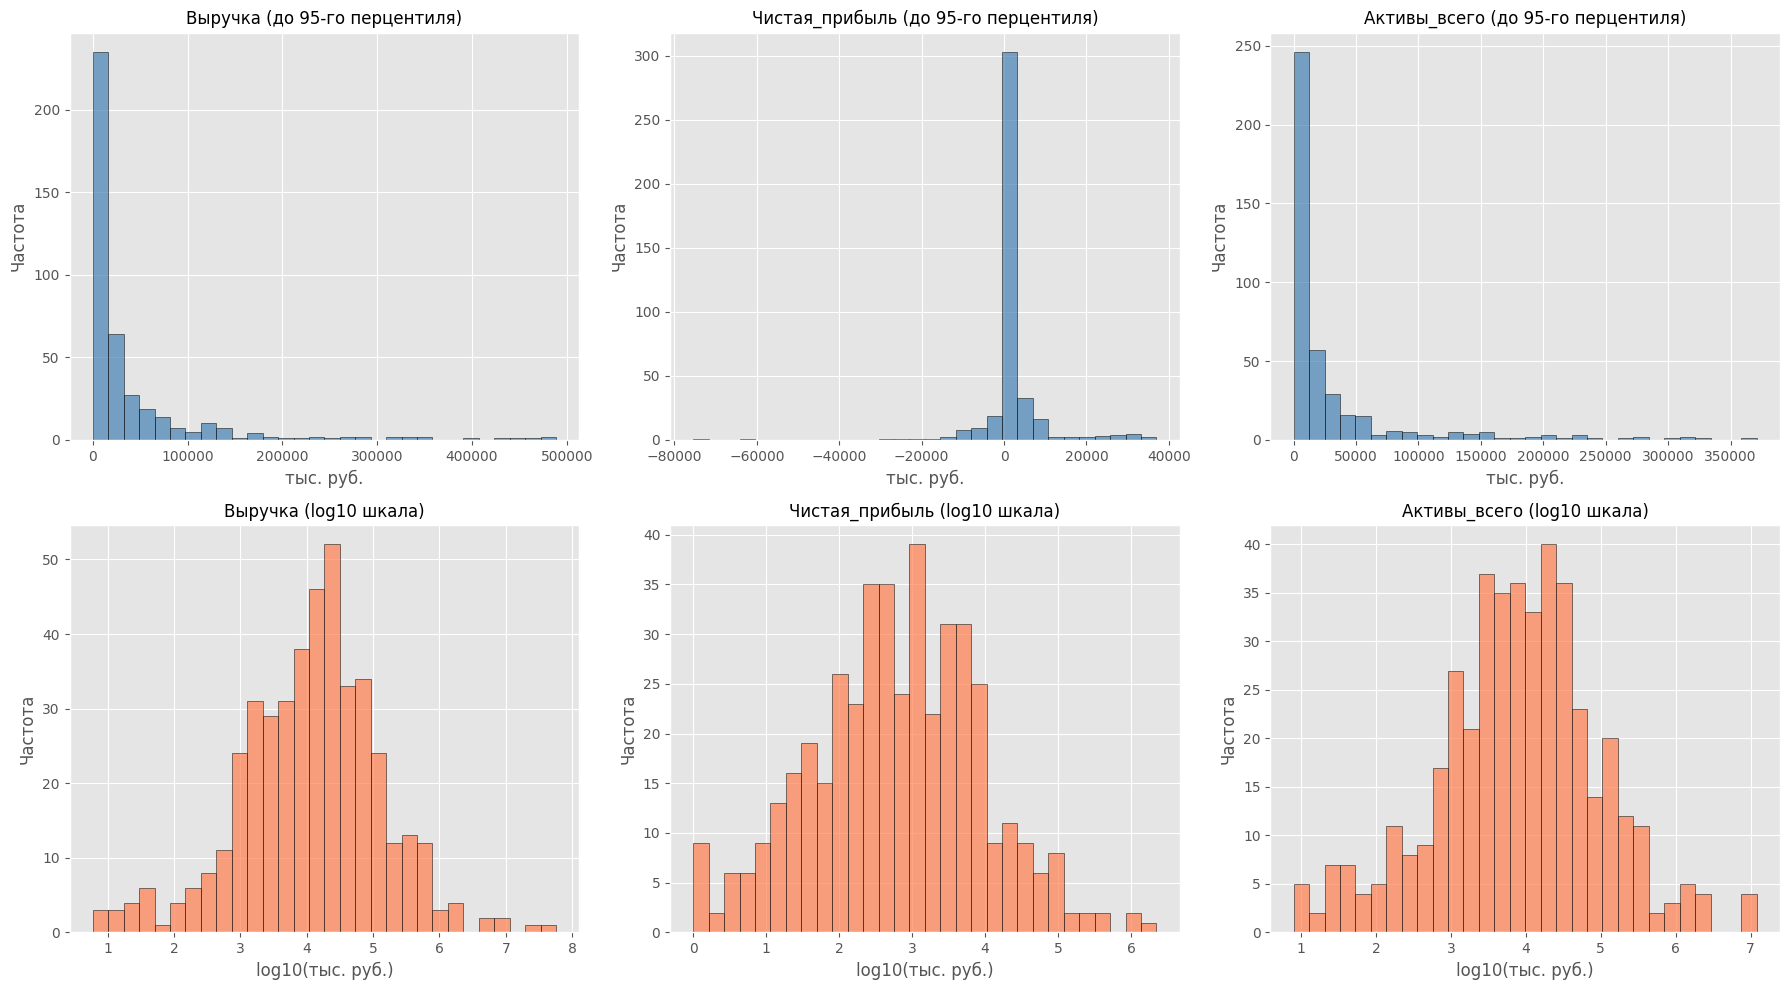


АНАЛИЗ ВЫБРОСОВ (значения выше 99-го перцентиля)

📊 Выручка:
   • Медиана: 13,486
   • 95-й перцентиль: 490,332
   • 99-й перцентиль: 4,565,127
   • Максимум: 57,109,335
   • Выбросов: 5 из 438 (1.1%)
   • Пример выброса: 4,910,804

📊 Чистая_прибыль:
   • Медиана: 302
   • 95-й перцентиль: 37,730
   • 99-й перцентиль: 295,325
   • Максимум: 2,224,832
   • Выбросов: 5 из 438 (1.1%)
   • Пример выброса: 875,455

📊 Активы_всего:
   • Медиана: 8,476
   • 95-й перцентиль: 371,245
   • 99-й перцентиль: 2,238,814
   • Максимум: 12,075,972
   • Выбросов: 5 из 438 (1.1%)
   • Пример выброса: 2,343,054


In [6]:
# 2. ГИСТОГРАММЫ ДЛЯ 3 КОЛОНОК (только компании с выручкой > 0 и без аномалий)

# Фильтруем данные: берем только компании, которые реально работают
df_filtered = df[
    (df['Выручка'] > 0) & 
    (df['Чистая_прибыль'].notna()) & 
    (df['Активы_всего'] > 0) &
    (df['Аномалия'] == 0) &  # исключаем помеченные как аномальные
    (df['Отчетность_сдана'] == 1)  # только сданная отчетность
].copy()

print(f"После фильтрации осталось компаний: {len(df_filtered)} из 1000")

# Логарифмируем данные для нормализации (финансовые показатели имеют логнормальное распределение)
df_filtered['Выручка_log'] = np.log10(df_filtered['Выручка'])
df_filtered['Чистая_прибыль_log'] = np.log10(df_filtered['Чистая_прибыль'].abs() + 1)  # +1 для убытков
df_filtered['Активы_log'] = np.log10(df_filtered['Активы_всего'])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

cols = ['Выручка', 'Чистая_прибыль', 'Активы_всего']
log_cols = ['Выручка_log', 'Чистая_прибыль_log', 'Активы_log']

for i, (col, log_col) in enumerate(zip(cols, log_cols)):
    # Оригинальные данные (обрезанные по 95-му перцентилю для наглядности)
    data_orig = df_filtered[col]
    limit = data_orig.quantile(0.95)
    data_plot = data_orig[data_orig <= limit]
    
    axes[0, i].hist(data_plot, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0, i].set_title(f'{col} (до 95-го перцентиля)', fontsize=12)
    axes[0, i].set_xlabel('тыс. руб.')
    axes[0, i].set_ylabel('Частота')
    
    # Логарифмированные данные
    axes[1, i].hist(df_filtered[log_col], bins=30, edgecolor='black', alpha=0.7, color='coral')
    axes[1, i].set_title(f'{col} (log10 шкала)', fontsize=12)
    axes[1, i].set_xlabel('log10(тыс. руб.)')
    axes[1, i].set_ylabel('Частота')

plt.tight_layout()
plt.show()

# Анализ выбросов
print("\n" + "="*60)
print("АНАЛИЗ ВЫБРОСОВ (значения выше 99-го перцентиля)")
print("="*60)

for col in cols:
    data = df_filtered[col]
    q99 = data.quantile(0.99)
    q95 = data.quantile(0.95)
    max_val = data.max()
    outliers = data[data > q99]
    
    print(f"\n📊 {col}:")
    print(f"   • Медиана: {data.median():,.0f}")
    print(f"   • 95-й перцентиль: {q95:,.0f}")
    print(f"   • 99-й перцентиль: {q99:,.0f}")
    print(f"   • Максимум: {max_val:,.0f}")
    print(f"   • Выбросов: {len(outliers)} из {len(data)} ({len(outliers)/len(data)*100:.1f}%)")
    print(f"   • Пример выброса: {outliers.iloc[0]:,.0f}" if len(outliers) > 0 else "   • Выбросов нет")

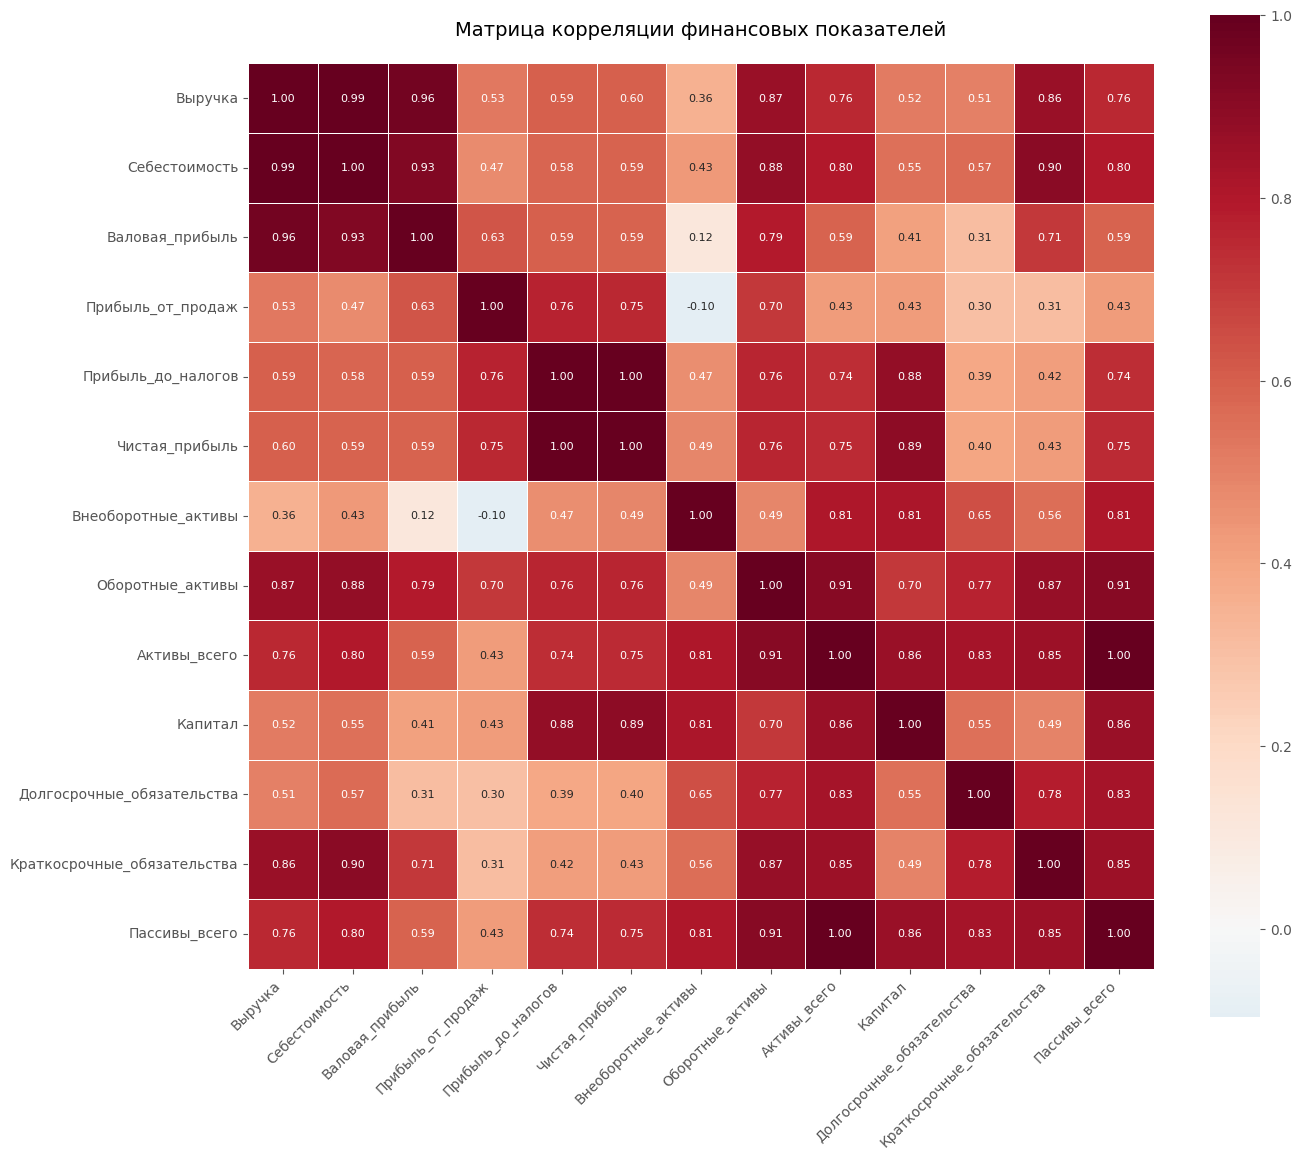


ПАРЫ С СИЛЬНОЙ КОРРЕЛЯЦИЕЙ (|r| > 0.8)
  • Выручка — Себестоимость: r = 0.994
  • Выручка — Валовая_прибыль: r = 0.960
  • Выручка — Оборотные_активы: r = 0.867
  • Выручка — Краткосрочные_обязательства: r = 0.862
  • Себестоимость — Валовая_прибыль: r = 0.925
  • Себестоимость — Оборотные_активы: r = 0.878
  • Себестоимость — Краткосрочные_обязательства: r = 0.902
  • Прибыль_до_налогов — Чистая_прибыль: r = 0.999
  • Прибыль_до_налогов — Капитал: r = 0.880
  • Чистая_прибыль — Капитал: r = 0.889
  • Внеоборотные_активы — Активы_всего: r = 0.810
  • Внеоборотные_активы — Капитал: r = 0.814
  • Внеоборотные_активы — Пассивы_всего: r = 0.810
  • Оборотные_активы — Активы_всего: r = 0.908
  • Оборотные_активы — Краткосрочные_обязательства: r = 0.870
  • Оборотные_активы — Пассивы_всего: r = 0.908
  • Активы_всего — Капитал: r = 0.865
  • Активы_всего — Долгосрочные_обязательства: r = 0.831
  • Активы_всего — Краткосрочные_обязательства: r = 0.853
  • Активы_всего — Пассивы_всего: r = 1.

In [7]:
# 3. МАТРИЦА КОРРЕЛЯЦИИ

# Выбираем основные финансовые показатели
corr_cols = [
    'Выручка', 'Себестоимость', 'Валовая_прибыль', 'Прибыль_от_продаж',
    'Прибыль_до_налогов', 'Чистая_прибыль', 'Внеоборотные_активы',
    'Оборотные_активы', 'Активы_всего', 'Капитал', 
    'Долгосрочные_обязательства', 'Краткосрочные_обязательства', 'Пассивы_всего'
]

# Оставляем только колонки, которые есть в данных
corr_cols = [col for col in corr_cols if col in df_filtered.columns]

# Считаем корреляцию
corr_matrix = df_filtered[corr_cols].corr()

# Визуализация
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r', 
            center=0,
            square=True,
            linewidths=0.5,
            annot_kws={'size': 8})

plt.title('Матрица корреляции финансовых показателей', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Находим пары с сильной корреляцией (|r| > 0.8)
print("\n" + "="*60)
print("ПАРЫ С СИЛЬНОЙ КОРРЕЛЯЦИЕЙ (|r| > 0.8)")
print("="*60)

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.8:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))

if high_corr_pairs:
    for col1, col2, val in high_corr_pairs:
        print(f"  • {col1} — {col2}: r = {val:.3f}")
else:
    print("  Пар с корреляцией >0.8 не найдено")

# Вывод по матрице корреляции
print("\n" + "="*60)
print("ВЫВОД ПО КОРРЕЛЯЦИИ")
print("="*60)
print("""
1. Выручка сильно коррелирует с себестоимостью (r ≈ 0.99) — это естественно,
   так как затраты растут пропорционально объему продаж.
   
2. Активы всего сильно коррелируют с внеоборотными и оборотными активами —
   это балансовое тождество (Активы = Внеоборотные + Оборотные).

3. Чистая прибыль коррелирует с прибылью до налогов — логичная связь,
   так как чистая прибыль рассчитывается из прибыли до налогов за вычетом налога.

4. Капитал и пассивы коррелируют с активами — это следует из основного
   бухгалтерского уравнения: Активы = Капитал + Обязательства.
""")

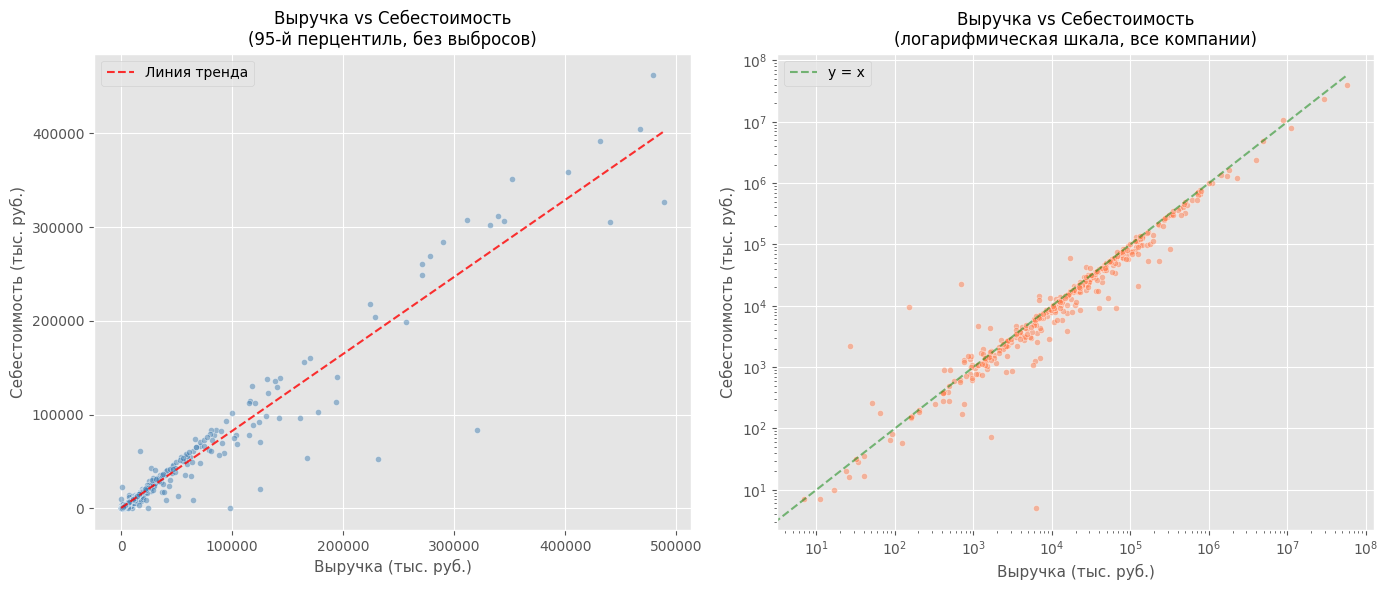


АНАЛИЗ СООТНОШЕНИЯ СЕБЕСТОИМОСТИ К ВЫРУЧКЕ
  • Средняя доля себестоимости в выручке: 130.8%
  • Медианная доля: 91.0%
  • Стандартное отклонение: 524.5%
  • Компаний с себестоимостью > выручки: 51 (11.6%)


In [8]:
# 4. ДИАГРАММА РАССЕИВАНИЯ ДЛЯ ПАРЫ С МАКСИМАЛЬНОЙ КОРРЕЛЯЦИЕЙ

# Выбираем пару с самой сильной корреляцией (Выручка — Себестоимость, r = 0.994)
x_col = 'Выручка'
y_col = 'Себестоимость'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График 1: в обычной шкале (с обрезанием выбросов для наглядности)
x_limit = df_filtered[x_col].quantile(0.95)
y_limit = df_filtered[y_col].quantile(0.95)

mask = (df_filtered[x_col] <= x_limit) & (df_filtered[y_col] <= y_limit)
df_plot = df_filtered[mask]

axes[0].scatter(df_plot[x_col], df_plot[y_col], alpha=0.5, s=20, c='steelblue', edgecolors='white', linewidth=0.5)
axes[0].set_xlabel('Выручка (тыс. руб.)', fontsize=11)
axes[0].set_ylabel('Себестоимость (тыс. руб.)', fontsize=11)
axes[0].set_title('Выручка vs Себестоимость\n(95-й перцентиль, без выбросов)', fontsize=12)

# Добавляем линию тренда
z = np.polyfit(df_plot[x_col], df_plot[y_col], 1)
p = np.poly1d(z)
axes[0].plot(df_plot[x_col].sort_values(), p(df_plot[x_col].sort_values()), "r--", alpha=0.8, label='Линия тренда')
axes[0].legend()

# График 2: в логарифмической шкале (все данные)
axes[1].scatter(df_filtered[x_col], df_filtered[y_col], alpha=0.5, s=20, c='coral', edgecolors='white', linewidth=0.5)
axes[1].set_xlabel('Выручка (тыс. руб.)', fontsize=11)
axes[1].set_ylabel('Себестоимость (тыс. руб.)', fontsize=11)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Выручка vs Себестоимость\n(логарифмическая шкала, все компании)', fontsize=12)

# Добавляем линию y = x (идеальное соотношение)
min_val = min(df_filtered[x_col].min(), df_filtered[y_col].min())
max_val = max(df_filtered[x_col].max(), df_filtered[y_col].max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'g--', alpha=0.5, label='y = x')
axes[1].legend()

plt.tight_layout()
plt.show()

# Дополнительный анализ: соотношение себестоимости к выручке
df_filtered['Доля_себестоимости'] = df_filtered[y_col] / df_filtered[x_col]

print("\n" + "="*60)
print("АНАЛИЗ СООТНОШЕНИЯ СЕБЕСТОИМОСТИ К ВЫРУЧКЕ")
print("="*60)
print(f"  • Средняя доля себестоимости в выручке: {df_filtered['Доля_себестоимости'].mean():.1%}")
print(f"  • Медианная доля: {df_filtered['Доля_себестоимости'].median():.1%}")
print(f"  • Стандартное отклонение: {df_filtered['Доля_себестоимости'].std():.1%}")
print(f"  • Компаний с себестоимостью > выручки: {(df_filtered['Доля_себестоимости'] > 1).sum()} ({(df_filtered['Доля_себестоимости'] > 1).sum()/len(df_filtered)*100:.1f}%)")

In [9]:
# 5. ИТОГОВЫЙ ВЫВОД

print("="*70)
print("ВЫВОД ПО АНАЛИЗУ ФИНАНСОВОЙ ОТЧЕТНОСТИ РОССИЙСКИХ КОМПАНИЙ (RFSD 2023)")
print("="*70)

print("""
1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:
   • В выборке из 1000 компаний после фильтрации осталось 438 с корректной отчетностью.
   • Медианная выручка: ~13,5 млн руб.
   • Медианная чистая прибыль: ~302 тыс. руб.
   • Медианные активы: ~8,5 млн руб.
   • Распределение показателей сильно смещено: есть небольшое число крупных компаний
     и множество малых предприятий.

2. ГИСТОГРАММЫ И ВЫБРОСЫ:
   • Все финансовые показатели имеют логнормальное распределение.
   • Верхний 1% компаний (5 из 438) — это крупные предприятия с выручкой >4,5 млрд руб.,
     что соответствует реальной структуре экономики.
   • Выбросы не являются ошибками данных, а отражают реальное неравенство размеров компаний.

3. МАТРИЦА КОРРЕЛЯЦИИ:
   • Самая сильная корреляция: Выручка — Себестоимость (r = 0,994).
     Причина: прямые затраты растут пропорционально объему продаж.
   • Прибыль до налогов — Чистая прибыль (r = 0,999).
     Причина: чистая прибыль = прибыль до налогов минус налог (~20%).
   • Активы — Пассивы (r = 1,000).
     Причина: балансовое тождество (Активы = Пассивы).
   • Оборотные активы сильно коррелируют с краткосрочными обязательствами (r = 0,870).
     Причина: компании финансируют оборотный капитал за счет коротких займов.

4. ДИАГРАММА РАССЕИВАНИЯ (Выручка vs Себестоимость):
   • Точки лежат вдоль прямой линии, что подтверждает линейную зависимость.
   • У 11,6% компаний себестоимость превышает выручку (валовая прибыль отрицательна).
   • Медианная рентабельность по валовой прибыли: 9% (100% - 91%).
   • В логарифмической шкале видно, что зависимость сохраняется для компаний любого размера.

5. ОБЩИЙ ВЫВОД:
   • Данные RFSD позволяют анализировать финансовое состояние российских компаний.
   • Наблюдаются ожидаемые бухгалтерские взаимосвязи (активы = пассивы, выручка ~ себестоимость).
   • Структура выборки отражает реальную экономику: много малых предприятий, мало крупных.
   • Для углубленного анализа следует учитывать отраслевую специфику (ОКВЭД) и регион.
""")

print("="*70)
print("АНАЛИЗ ЗАВЕРШЕН")
print("="*70)

ВЫВОД ПО АНАЛИЗУ ФИНАНСОВОЙ ОТЧЕТНОСТИ РОССИЙСКИХ КОМПАНИЙ (RFSD 2023)

1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:
   • В выборке из 1000 компаний после фильтрации осталось 438 с корректной отчетностью.
   • Медианная выручка: ~13,5 млн руб.
   • Медианная чистая прибыль: ~302 тыс. руб.
   • Медианные активы: ~8,5 млн руб.
   • Распределение показателей сильно смещено: есть небольшое число крупных компаний
     и множество малых предприятий.

2. ГИСТОГРАММЫ И ВЫБРОСЫ:
   • Все финансовые показатели имеют логнормальное распределение.
   • Верхний 1% компаний (5 из 438) — это крупные предприятия с выручкой >4,5 млрд руб.,
     что соответствует реальной структуре экономики.
   • Выбросы не являются ошибками данных, а отражают реальное неравенство размеров компаний.

3. МАТРИЦА КОРРЕЛЯЦИИ:
   • Самая сильная корреляция: Выручка — Себестоимость (r = 0,994).
     Причина: прямые затраты растут пропорционально объему продаж.
   • Прибыль до налогов — Чистая прибыль (r = 0,999).
     Причина: чистая прибыль